In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
def load_tsv(file):
    tokens = []
    true_tags = []
    pred_tags = []
    
    with open(file, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line.split("\t")[0] == "sentence_idx":
                continue
            _, _, tok, true_tag, pred_tag = line.split("\t")
            tokens.append(tok)
            true_tags.append(true_tag)
            pred_tags.append(pred_tag)

    return tokens, true_tags, pred_tags

In [3]:
tokens, true_tags, pred_tags = load_tsv("test_predictions.tsv")

In [4]:
wrong_predictions = []

for token, true_tag, pred_tag in zip(tokens, true_tags, pred_tags):
    if true_tag != pred_tag:
        wrong_predictions.append((token, true_tag, pred_tag))

print(f"Total wrong predictions:{len(wrong_predictions)}\n")
for token, true, pred in wrong_predictions[:20]:
    print(f"Token: {token}\tTrue: {true}\tPredicted: {pred}")

Total wrong predictions:1190

Token: contrast	True: B	Predicted: O
Token: media	True: I	Predicted: O
Token: contrast	True: B	Predicted: O
Token: materials	True: I	Predicted: O
Token: PRC	True: B	Predicted: O
Token: PRC	True: B	Predicted: O
Token: PRC	True: B	Predicted: O
Token: (	True: O	Predicted: I
Token: +	True: O	Predicted: I
Token: )	True: O	Predicted: I
Token: (	True: O	Predicted: I
Token: +	True: O	Predicted: I
Token: )	True: O	Predicted: I
Token: (	True: O	Predicted: I
Token: +	True: O	Predicted: I
Token: )	True: O	Predicted: I
Token: (	True: O	Predicted: I
Token: +	True: O	Predicted: I
Token: )	True: O	Predicted: I
Token: (	True: O	Predicted: I


In [5]:
confusion_counts = Counter([(true_tag, pred_tag) for _, true_tag, pred_tag in wrong_predictions])

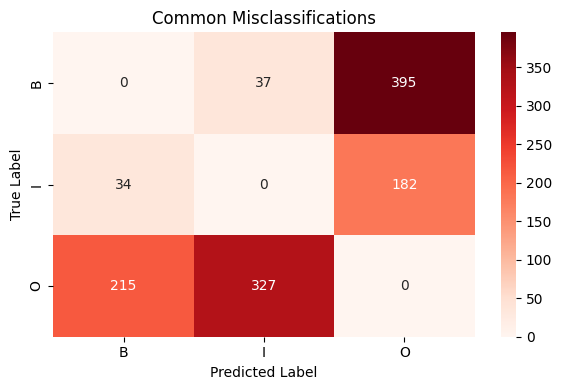

In [6]:
confusion_df = pd.DataFrame(
    [(true, pred, count) for (true, pred), count in confusion_counts.items()],
    columns=['True', 'Predicted', 'Count']
)

heatmap_data = confusion_df.pivot(index='True', columns='Predicted', values='Count').fillna(0)

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Reds")
plt.title("Common Misclassifications")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

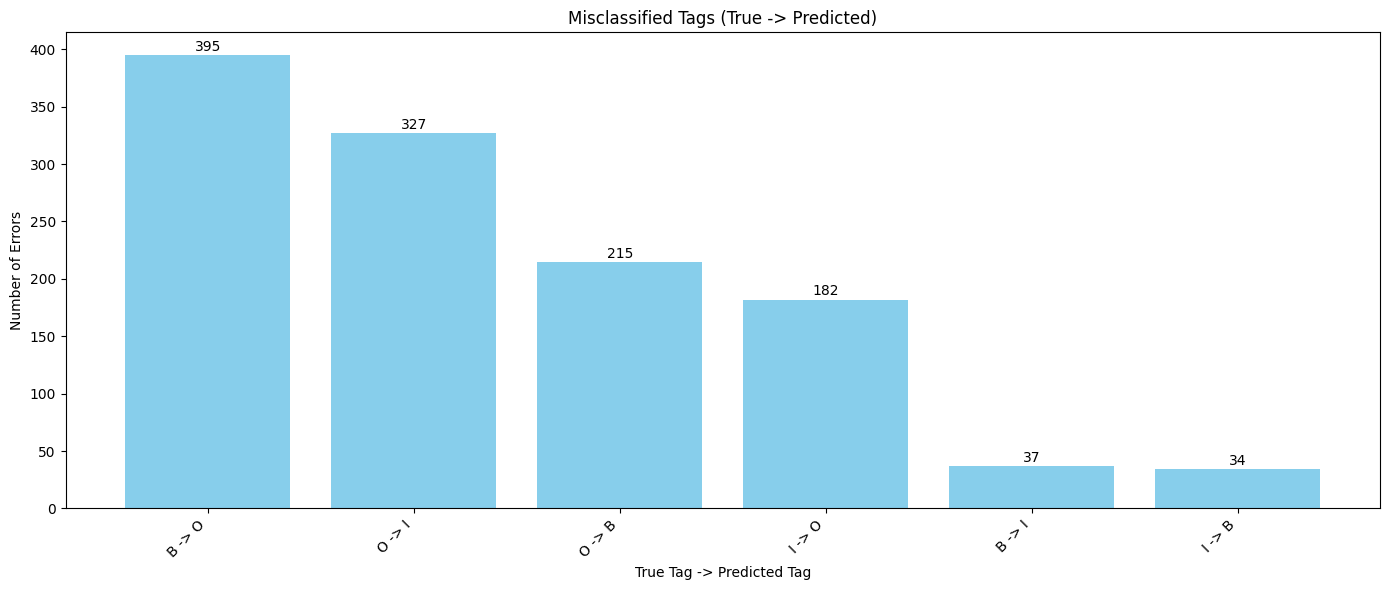

In [7]:
labels = [f"{true} -> {pred}" for true, pred in confusion_counts]
counts = list(confusion_counts.values())

sorted_data = sorted(zip(labels, counts), key=lambda x: x[1], reverse=True)
sorted_labels, sorted_counts = zip(*sorted_data)

plt.figure(figsize=(14, 6))
bars = plt.bar(sorted_labels, sorted_counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("True Tag -> Predicted Tag")
plt.ylabel("Number of Errors")

plt.title("Misclassified Tags (True -> Predicted)")
plt.tight_layout()

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1 , int(yval), ha='center', va='bottom')
plt.show()

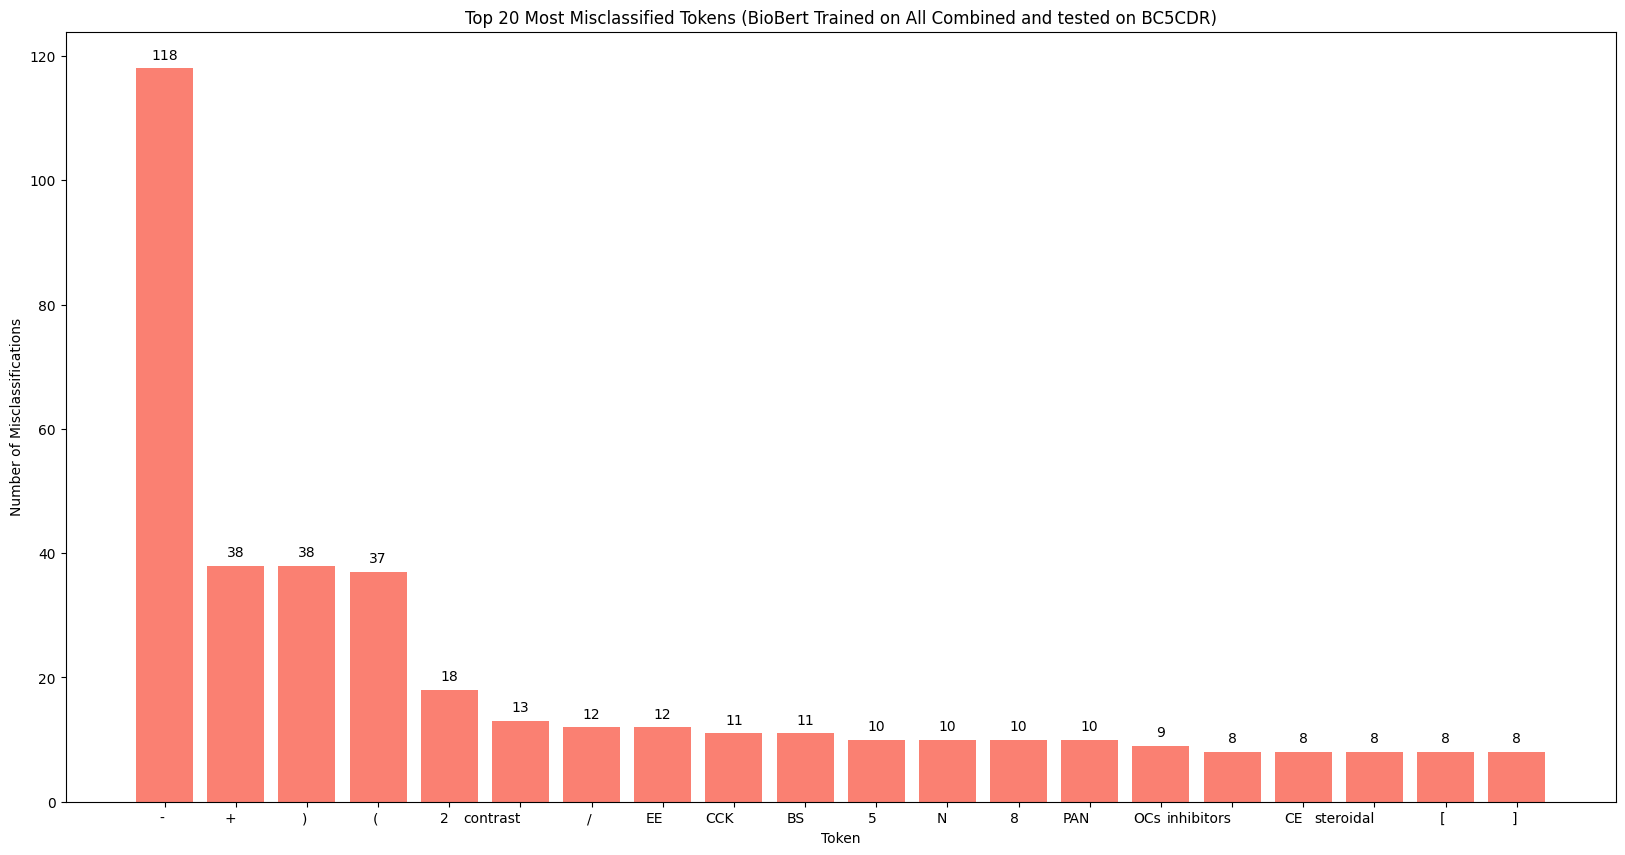

In [8]:
token_errors = Counter([token for token, _, _ in wrong_predictions])
top_tokens = token_errors.most_common(20)
tokens, counts = zip(*top_tokens)
plt.figure(figsize=(20,10))
bars = plt.bar(tokens, counts, color='salmon')
plt.xlabel("Token")
plt.ylabel("Number of Misclassifications")
plt.title("Top 20 Most Misclassified Tokens (BioBert Trained on All Combined and tested on BC5CDR)")
plt.xticks(rotation=0, ha='right')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')
plt.show()